## Multi-commodity flow formulation for the CVRP

##### Keywords:  CVRP, Subtours, Linear Programming, Cplex, Python, Networkx, Docplex, Multi-Commodity Flow

$ \text{Variables} $

$x_{ij}={\begin{cases}1&{\text{the path goes from city }}i{\text{ to city }}j\\0&{\text{otherwise}}\end{cases}}$

$G_{ij}=\text{represents the load of the vehicle by
the time it departs from node i, and $G_{ji}$ indicates the residual capacity of the vehicle} $  $\quad ~~~~~~\text{on the same edge (i,j). Note that $G_{ji}=Q-G_{ij}$ holds true whenever $x_{ij}=1$ }$

\begin{equation*}
\begin{aligned}
& \underset{}{\text{Minimize}}
& & \sum_{i=1}^{n} \sum_{j=1, i\neq j}^{n+1} c_{ij} x_{ij} + \sum_{i=1}^{n} C_{i(n+1)}x_{i(n+1)} \\
& \text{Subject to}
& & \sum_{j=1, j\neq i}^{n+1} (G_{ji}-G_{ij}) = 2q, \quad i = 2,\ldots,n, \\
& 
& & \sum_{j=2}^{n} G_{0j} = \sum_{j=2}^{n} q_{j} \\
&
& & \sum_{j=2}^{n} G_{j0} = kQ - \sum_{j=2}^{n} q_{j} \\
&
& & \sum_{j=2}^{n} G_{(n+1)j} = kQ \\
&
& & G_{ij}+G_{ji} = Qx_{ij}, \quad i,j =1, \ldots,(n+1), i\neq j,i\neq (n+1)  \,\\
&
& & \underset{\text{$j>i$}}{\text{$\sum_{j=1}^{n+1} x_{ij}$}} + \underset{\text{$j<i$}}{\text{$\sum_{j=1}^{n+1} x_{ji}$}}= 2, \quad i =2, \ldots,n, i\neq j\,\\
&
& & x_{ij} \in \{0,1\}, \quad i,j = 1,\ldots,(n+1), \, i\neq j, \\
&
& & G_{ij} \ge 0, \quad i,j=1,\ldots ,(n+1).
\end{aligned}
\end{equation*}


#### Import Library and Model Enviroment

In [1]:
from docplex.mp.model import Model
import networkx as nx   
import numpy as np
import matplotlib.pyplot as plt
import math
mdl=Model('Multi-commodity flow CVRP')

#### Function to Import the Data

In [2]:
def import_txt(filename):
    """
    This function imports data from a Vehicle Routing Problem (VRP) instance from a text file.

    Parameters:
    file (str): The name of the file (without the .vrp extension) that contains the VRP instance data.

    Returns:
    coord_x (list): A list of the x-coordinates of the nodes in the VRP instance.
    coord_y (list): A list of the y-coordinates of the nodes in the VRP instance.
    Name (str): The name of the VRP instance.
    Nodes (int): The number of nodes in the VRP instance.
    Capacity (int): The capacity of the vehicles in the VRP instance.
    Trucks (int): The number of trucks available in the VRP instance.
    Demand (list): A list of the demands at each node in the VRP instance.
    N (list): A list of the node numbers in the VRP instance.
    Arc (list): A list of tuples representing all possible arcs between nodes in the VRP instance.
    
    #For this example, we need to create an extra depot, so we duplicate the depot and we add it at the end. 

    Usage Example:
    coord_x, coord_y, Name, Nodes, Capacity, Trucks, D, N, Arc = import_txt('my_vrp_instance')
    """
    file = open(filename+'.vrp') 
    Data = file.readlines()
    file.close()
    Name= str(Data[0].split()[2])
    Nodes= int(Data[3].split()[2])
    Capacity= int(Data[5].split()[2])
    Trucks = int((Data[1].split()[8]).replace(",",""))
    coord_x=[int(Data[i].split()[1]) for i in range(7,7+Nodes)]
    coord_y=[int(Data[i].split()[2]) for i in range(7,7+Nodes)]
    coord_x.append(coord_x[0])
    coord_y.append(coord_y[0])
    print(coord_x)
    print(coord_y)
    Demand=[int(Data[i].split()[1]) for i in range(7+Nodes+1,7+Nodes+1+Nodes)]
    Demand.append(Demand[0])
    N=[i+1 for i in range(Nodes+1)] #+1 because of the extra depot
    Arc =[(i,j) for i in N for j in N if i!=j]
    
    
    return coord_x,coord_y,Name,Nodes,Capacity,Trucks,Demand,Arc

#### Create dictonary of Distances

In [3]:
def distance(coord_x, coord_y, arcos):
    """
    This function calculates the Euclidean distance (Int) between each pair of nodes in a Vehicle Routing Problem (VRP) instance.

    Parameters:
    coord_x (list): A list of the x-coordinates of the nodes in the VRP instance.
    coord_y (list): A list of the y-coordinates of the nodes in the VRP instance.
    arcos (list): A list of tuples representing all possible arcs between nodes in the VRP instance.

    Returns:
    distancia (dict): A dictionary where the keys are the arcs (pairs of nodes) and the values are the Euclidean distances between the nodes.

    """

    distance = {(i, j): round(math.sqrt((coord_x[i-1] - coord_x[j-1])**2 + (coord_y[i-1] - coord_y[j-1])**2),2) for i,j in arcos}
    
    return distance


In [4]:
coord_x,coord_y,Name,Nodes,Capacity,Trucks,Demand,Arc=import_txt("P-n16-k8")

[30, 37, 49, 52, 31, 52, 42, 52, 57, 62, 42, 27, 43, 58, 58, 37, 30]
[40, 52, 49, 64, 62, 33, 41, 41, 58, 42, 57, 68, 67, 48, 27, 69, 40]


#### Parameters

In [5]:
C=distance(coord_x,coord_y, Arc)
k=Trucks
Q=Capacity
q=Demand
dc=Nodes+1 #depot copy

In [6]:
print(C)
print(k)
print(Q)
print(q)
print(dc)

{(1, 2): 13.89, (1, 3): 21.02, (1, 4): 32.56, (1, 5): 22.02, (1, 6): 23.09, (1, 7): 12.04, (1, 8): 22.02, (1, 9): 32.45, (1, 10): 32.06, (1, 11): 20.81, (1, 12): 28.16, (1, 13): 29.97, (1, 14): 29.12, (1, 15): 30.87, (1, 16): 29.83, (1, 17): 0.0, (2, 1): 13.89, (2, 3): 12.37, (2, 4): 19.21, (2, 5): 11.66, (2, 6): 24.21, (2, 7): 12.08, (2, 8): 18.6, (2, 9): 20.88, (2, 10): 26.93, (2, 11): 7.07, (2, 12): 18.87, (2, 13): 16.16, (2, 14): 21.38, (2, 15): 32.65, (2, 16): 17.0, (2, 17): 13.89, (3, 1): 21.02, (3, 2): 12.37, (3, 4): 15.3, (3, 5): 22.2, (3, 6): 16.28, (3, 7): 10.63, (3, 8): 8.54, (3, 9): 12.04, (3, 10): 14.76, (3, 11): 10.63, (3, 12): 29.07, (3, 13): 18.97, (3, 14): 9.06, (3, 15): 23.77, (3, 16): 23.32, (3, 17): 21.02, (4, 1): 32.56, (4, 2): 19.21, (4, 3): 15.3, (4, 5): 21.1, (4, 6): 31.0, (4, 7): 25.08, (4, 8): 23.0, (4, 9): 7.81, (4, 10): 24.17, (4, 11): 12.21, (4, 12): 25.32, (4, 13): 9.49, (4, 14): 17.09, (4, 15): 37.48, (4, 16): 15.81, (4, 17): 32.56, (5, 1): 22.02, (5, 2):

#### Sets

In [7]:
N=[i+1 for i in range(Nodes+1)] #+1 because of the extra depot
N_=[i+1 for i in range(Nodes)] #depot and client

#### Index

In [8]:
Ind1={(i,j) for i in N for j in N}
Ind2={(i,j) for i in N for j in N}

#### Variables

In [9]:
x=mdl.binary_var_dict(Ind1, name='x')
G=mdl.continuous_var_dict(Ind2, name='G')

#### Mathematical Model of the Multi-commodity flow formulation for the Capacited Vehicle Routing Problem (Multi-commodity flow CVRP)

#### Objective Function

In [10]:
mdl.minimize(mdl.sum(C[i,j]*x[i,j] for i in N_ for j in N_ if i!=j)+mdl.sum(C[i,dc]*x[i,dc] for i in N_ if i!=1 if i!=dc))

#### Subject to:

In [11]:
for i in N_:
    if i!=1:
        mdl.add_constraint(mdl.sum(G[j,i]-G[i,j] for j in N)==2*q[i-1])

In [12]:
mdl.add_constraint(mdl.sum(G[1,j] for j in N_ if j!=1)==mdl.sum(q[j-1] for j in N_ if j!=1))


docplex.mp.LinearConstraint[](G_1_6+G_1_11+G_1_12+G_1_15+G_1_16+G_1_5+G_1_10+G_1_3+G_1_14+G_1_4+G_1_9+G_1_7+G_1_2+G_1_13+G_1_8,EQ,246)

In [13]:
mdl.add_constraint(mdl.sum(G[j,1] for j in N_ if j!=1)==k*Q-mdl.sum(q[j-1] for j in N_ if j!=1 ))


docplex.mp.LinearConstraint[](G_12_1+G_15_1+G_14_1+G_3_1+G_2_1+G_5_1+G_4_1+G_7_1+G_6_1+G_16_1+G_9_1+G_8_1+G_11_1+G_10_1+G_13_1,EQ,34)

In [14]:
mdl.add_constraint(mdl.sum(G[dc,j] for j in N_ if j!=1)==k*Q)

docplex.mp.LinearConstraint[](G_17_7+G_17_2+G_17_13+G_17_8+G_17_6+G_17_11+G_17_12+G_17_15+G_17_5+G_17_10+G_17_3+G_17_16+G_17_14+G_17_4+G_17_9,EQ,280)

In [15]:
for i in N:
    for j in N:
        if i!=j:
            if i!=dc:
                mdl.add_constraint(G[i,j]+G[j,i]==Q*x[i,j])

In [16]:
for i in N_:
    if i!=1:
        mdl.add_constraint(mdl.sum(x[i,j] for j in N if j>i)+mdl.sum(x[j,i] for j in N if j<i)==2)

In [17]:
for i in N:
    for j in N:
        mdl.add_constraint(G[i,j]>=0)

Version identifier: 12.10.0.0 | 2019-11-26 | 843d4de2ae
CPXPARAM_Read_DataCheck                          1
CPXPARAM_RandomSeed                              201903125
Tried aggregator 1 time.
MIP Presolve eliminated 290 rows and 53 columns.
Reduced MIP has 288 rows, 525 columns, and 1530 nonzeros.
Reduced MIP has 255 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (0.70 ticks)
Probing time = 0.00 sec. (0.13 ticks)
Tried aggregator 1 time.
MIP Presolve eliminated 120 rows and 120 columns.
Reduced MIP has 168 rows, 405 columns, and 1170 nonzeros.
Reduced MIP has 135 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (0.79 ticks)
Probing time = 0.00 sec. (0.05 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 168 rows, 405 columns, and 1170 nonzeros.
Reduced MIP has 135 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (0.58 ticks)
Probing time = 0.00 sec. (0.05 ticks)
MIP emphasis: balance optim

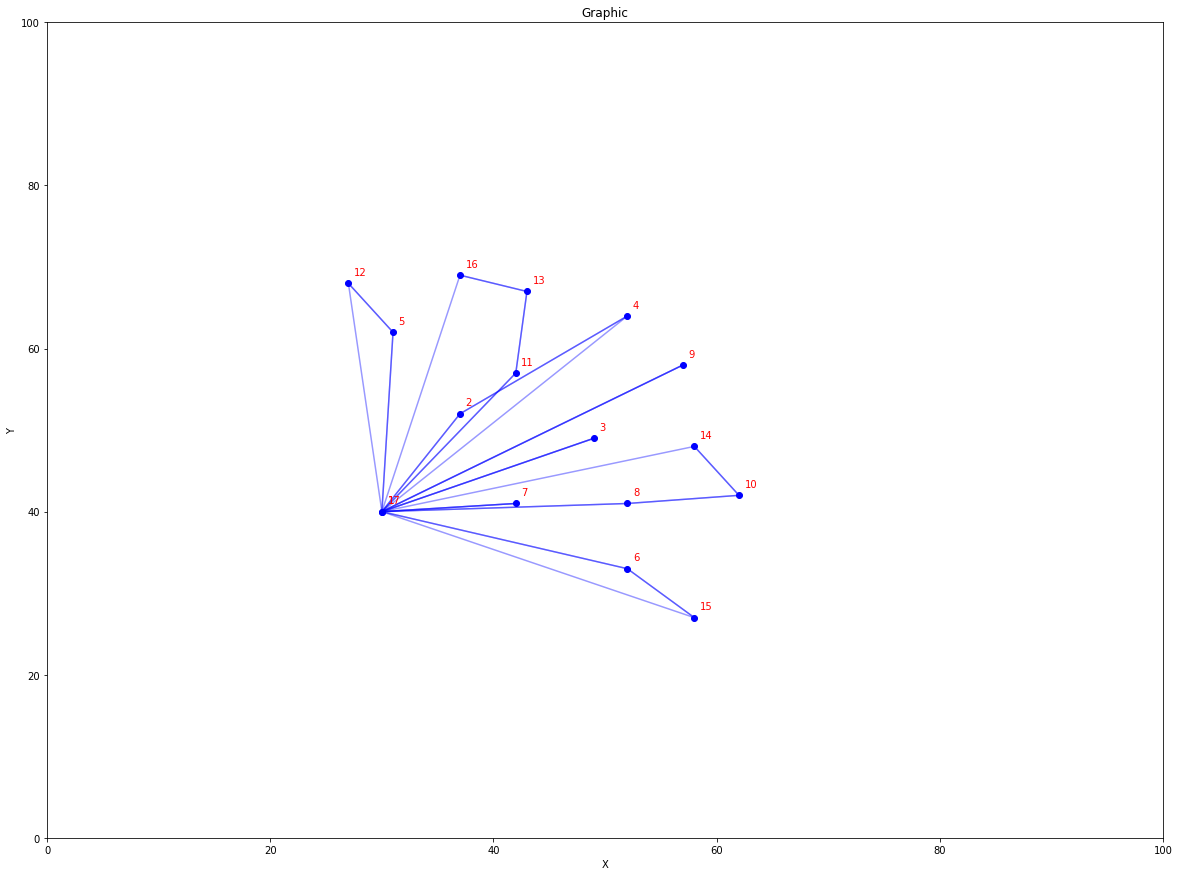

In [18]:
"""
This script uses the CPLEX optimization library to solve a Vehicle Routing Problem (VRP) instance. 

First, it sets a time limit for the optimization process using the `mdl.parameters.timelimit` attribute. Then, it solves the problem and displays the solution using the `mdl.solve` and `solucion.display` methods, respectively.

The solution is then extracted into two dictionaries, `sx` and `su`, using the `solucion.get_value_dict` method. These dictionaries contain the solution values for the decision variables `x` and `u`, respectively.

Finally, the script plots the solution on a graph. The nodes are represented as points, and the arcs that are included in the solution are represented as lines between the points. The plot includes labels for the nodes and axes, and a title.

Parameters:
mdl (Model): The CPLEX model object representing the VRP instance.
x (dict): A dictionary where the keys are the arcs (pairs of nodes) and the values are the decision variables representing whether or not each arc is included in the solution.
u (dict): A dictionary where the keys are the nodes and the values are the decision variables representing the load of each vehicle at each node.
coord_x (list): A list of the x-coordinates of the nodes in the VRP instance.
coord_y (list): A list of the y-coordinates of the nodes in the VRP instance.
Arc (list): A list of tuples representing all possible arcs between nodes in the VRP instance.
N (list): A list of the node numbers in the VRP instance.

Usage Example:
# Assuming `mdl`, `x`, `coord_x`, `coord_y`, `Arc`, and `N` are already defined...
mdl.parameters.timelimit = 300
solucion = mdl.solve(log_output=True)
solucion.display()
sx = solucion.get_value_dict(x, keep_zeros=True, precision=1)
su = solucion.get_value_dict(u, keep_zeros=True, precision=1)
# Plotting code here...
"""

#661
#mdl.parameters.timelimit=500
solucion=mdl.solve(log_output=True)
solucion.display()
sx=solucion.get_value_dict(x, keep_zeros=True, precision=1)

plt.figure(figsize=(20,15))#size of the figure
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Graphic")#title

actives_arcs = [i for i in Arc if x[i].solution_value > 0.9]

for i,j in actives_arcs:
    plt.plot([coord_x[i-1],coord_x[j-1]],[coord_y[i-1],coord_y[j-1]],color='b', alpha=0.4, zorder=0)
    
plt.scatter(x=coord_x, y=coord_y, color='blue', zorder=1)
  
for n in N:
    plt.annotate(str(n), xy=(coord_x[n-1],coord_y[n-1] ), xytext=(coord_x[n-1]+0.5,coord_y[n-1]+1),color='red')

plt.xlim((0,100))
plt.ylim((0,100))
plt.show()

$ Literature $

Aksen, D., Oncan, T., & Sadati, M.E. (2018). An Empirical Investigation of Four Well-Known Polynomial-Size VRP Formulations. arXiv: Optimization and Control. pp. 1-5.

Capacitated Vehicle Routing Problem Library http://vrp.galgos.inf.puc-rio.br/index.php/en/



In [19]:
#Profesor Francisco extraccion instancias, revisar luego

# class Data:

#     def __init__(self, filename):   

#         #Abrir archivo
#         file = open(filename)
#         Data = file.readlines()
#         file.close()

#         self.n = int(Data[3].split()[2]) - 1      
#         self.C = float(Data[5].split()[2])#Float 
        
#         #Lee los datos
#         n = self.n
       
        
#         lista = []
#         for i in range(7,n+8):
#             lista.append({})
#             index = len(lista)-1
#             lista[index]['x']=float(Data[i].split()[1])
#             lista[index]['y']=float(Data[i].split()[2])
#             lista[index]['q']=float(Data[i+n+2].split()[1])
#             listapropio[-1]['x'].append(listapropio[0]['x'])
#             listapropio[-1]['y'].append(listapropio[0]['y'])

#         listapropio = lista
#         listapropio.append(lista[0])
#         c = np.ones((n+1, n+1))*(100000)
        
#         #Calcula las distancias y crea lista de costos
#         for i in range(n+1):
#             for j in range(n+1):
#                 if i != j:
#                     c[i][j] = np.sqrt(pow(listapropio[j]['x']-listapropio[i]['x'],2) 
#                                       + pow(listapropio[j]['y']-listapropio[i]['y'],2))
#                 if i == j: 
#                     c[i][j] = 0

#                 if (i == len(listapropio)-1 and j==0) or (j== len(listapropio)-1 and i==0):
#                     c[i][j] =0
                    
#                 dec = c[i][j] - int(c[i][j])
                
# #                 if dec < 0.5:
# #                     c[i][j]=int(mt.floor(c[i][j]))
# #                 else: 
# #                     c[i][j]=int(mt.ceil(c[i][j]))
                    
#         #################################Verificación de desigualdad Triangular##############################
#         cambia=False
#         c2 =c.copy()        
#         for k in range(n+1):
#             for i in range(n+1):
#                 for j in range(n+1):
#                     c3=c2[i][k]+c2[k][j]
#                     if c3<c2[i][j] and i!=j:
#                         c2[i][j]=c3
#                         cambia=True
                        
#         if cambia==True:
#             c=c2.copy()
#         #####################################################################################################
        
#         self.c = c.astype(float)
        
#         #Crea las listas con los datos
#         index = len(listapropio)
#         q = np.zeros(n+1)
        
        
#         for i in range(n+1):
#             q[i] = int(listapropio[i]['q'])
        
#         self.q = q.astype(float)
        
#         self.E=1e-6
        
#         demanda_total = 0
#         for i in range(1,n+1):
#             demanda_total= demanda_total+self.q[i]


#         self.n=n+1
        
#         print('n=',self.n,'c=', self.C)#, 'k=', self.h)
        
#         a=[]
#         for i in range(n+1):
#             a.append(listapropio[i]['x'])
        
#         self.a=a
#         o=[]
#         for i in range(self.n):
#             o.append(listapropio[i]['y'])
        
#         self.o=o

        
# #data=Data(filename)
   

$ Literature $

Aksen, D., Oncan, T., & Sadati, M.E. (2018). An Empirical Investigation of Four Well-Known Polynomial-Size VRP Formulations. arXiv: Optimization and Control. pp. 1-5.

Capacitated Vehicle Routing Problem Library http://vrp.galgos.inf.puc-rio.br/index.php/en/

